# Clustering

- It is a unsupervised Machine Learning technique trains on unlabeled data.
- It groups data based on similarites or distance measured
- It doesn't require any predefined labels
- It discovers hidden patterns and natural groupings
- This is best for eda, customer segmentation, anomaly detection and image recognization
- Similarities can be measured using euclidean distance or cosine similarity


### Types of clustering
1. Partition based
2. Density Based
3. Hierarchical Based


## 1. Partition Based

Partition clustering is a family of algorithms that divide a dataset into a fixed number of disjoint clusters based on similarity, ensuring each data point belongs to exactly one cluster (except in fuzzy methods where partial memberships are allowed) . These methods aim to maximize intra-cluster similarity and minimize inter-cluster similarity, often by optimizing an objective function such as the sum of squared distances or dissimilarities.

#### Popular algorithms include:

- K-Means – centroid-based, minimizes squared distances.

- K-Medoids (PAM) – medoid-based, more robust to noise/outliers.




# K Means  (Partition based)

- Kmeans clustering is a unsupervised machine learning algorithm used to group data points into clusters based on their similarity.
- It is particulary used when working with unlabeled data to uncover hidden patterns (or) structures.

- The algorithm aims to partition the dataset into k clusters.
- fails near outliers
- fails to clusters that are non spherical clusters
- we have to define k no clusters.

-  higher k value -> smaller clusters with greater detail.
- lower K value -> Bigger cluster with less detail.


### Working of K-Means Algorithm (Centroid-Based)

- Initialize: Randomly select K centroids.

- Assign: Allocate each point to the nearest centroid.

- Update: Recalculate centroids as the mean of assigned points.

- Repeat until assignments stabilize or max iterations reached.


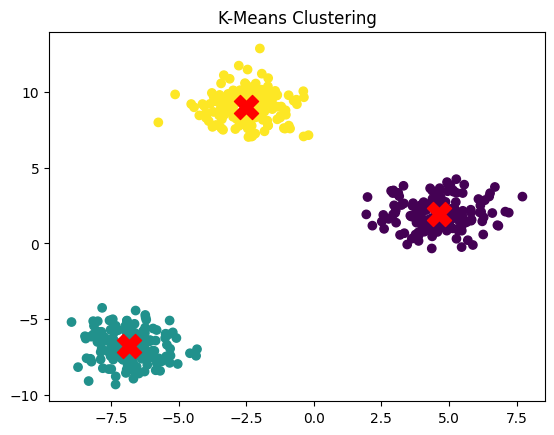

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
# Generate synthetic dataset
X, _ = make_blobs(n_samples=500, centers=3, random_state=42)
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X')
plt.title("K-Means Clustering")
plt.show()

## Accuracy

we use sihouette score : that measures how similar a point is in its own custer vs other cluster

- range: -1 to 1
- higher score -> better cluster formed

## Apply clustering techniques

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import hdbscan

import warnings
warnings.filterwarnings("ignore")


In [4]:
df=pd.read_csv('/content/Mall_Customers.csv')

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


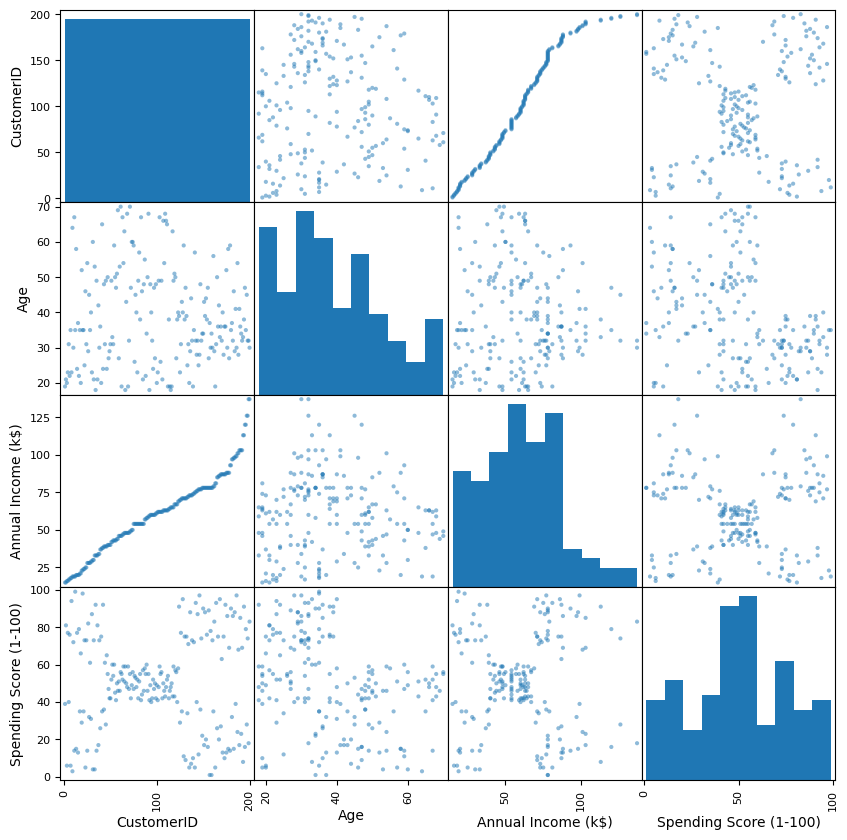

In [6]:
pd.plotting.scatter_matrix(df,figsize=(10,10))
plt.show()

In [11]:
X=df[['Annual Income (k$)', 'Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


K Means Clustering

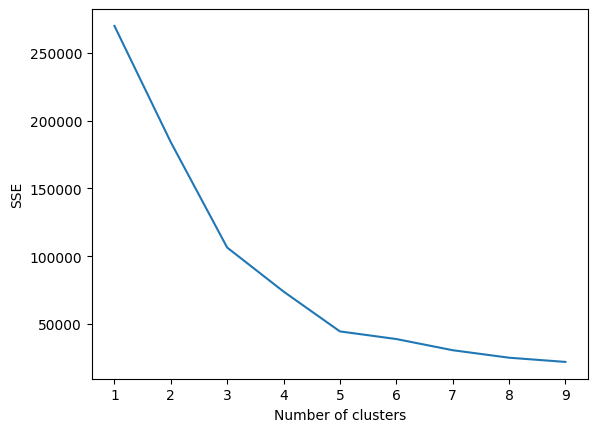

In [14]:
sse=[] # sum of sqaured error(inertia)
for i in range(1,10):   # try to find k optimal cluster
  km=KMeans(n_clusters=i)
  km.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']]) # X
  sse.append(km.inertia_)
plt.xlabel("Number of clusters")
plt.ylabel(("SSE"))
plt.plot(range(1,10),sse)

#### so here we can see by using elbow method we can determine that at level 5 cluster starts decling which optimal no of clusters

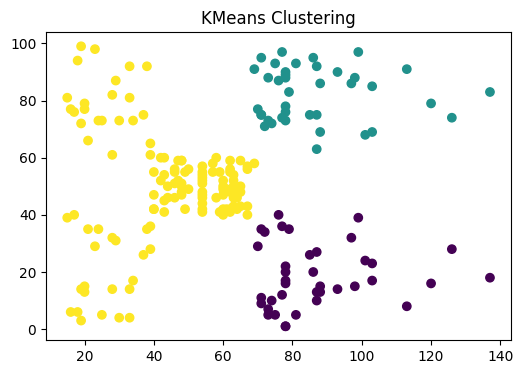

In [18]:
Kmeans=KMeans(n_clusters=5, random_state=42)
kmeans_labels=kmeans.fit_predict(X) # passing fetaures

plt.figure(figsize=(6,4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clustering")
plt.show()

## 2. Hierarchical clustering

- It organizes data into nested clusters
which contains smaller subb clusters like trees

- It is applicable for small to medium data  only cause large data takes so much time.

### Types of Hierarchical Clustering

There are two main types of hierarchical clustering:

1. Agglomerative Clustering: This is a "bottom-up" approach where each data point starts as its own cluster, and pairs of clusters are merged as one moves up the hierarchy. It does not require a predefined number of clusters.

2. Divisive Clustering(applies only theoritically): This is a "top-down" approach where all data points start in one cluster, and splits are performed recursively as one moves down the hierarchy. It also does not require a predefined number of clusters.



### Workflow for Hierarchical Divisive Clustering

1. Start with all data points in one cluster: Treat the entire dataset as a single large cluster.

2. Split the cluster: Divide the cluster into two smaller clusters.

3. Repeat the process: For each of the new clusters, repeat the splitting process until every data point is its own cluster or the stopping condition is met.




### Dendrogram

A dendrogram is a tree-like diagram that visually represents the hierarchical structure of clusters. It shows how data points or clusters are merged or split at each step of the clustering process, with the height of the branches indicating the distance at which the merging or splitting occurs.

## Agglomerative Clustering



### Workflow for Hierarchical Agglomerative Clustering

1. Start with individual points: Each data point is its own cluster.

2. Calculate distances between clusters: Calculate the distance between every pair of clusters.

3. Merge the closest clusters: Identify the two clusters with the smallest distance and merge them into a single cluster.

4. Update distance matrix: Recalculate the distances between the new cluster and the remaining clusters.

5. Repeat steps 3 and 4: Continue merging the closest clusters and updating the distance matrix until only one cluster is left.

6. Create a dendrogram: Visualize the merging of clusters using a dendrogram.

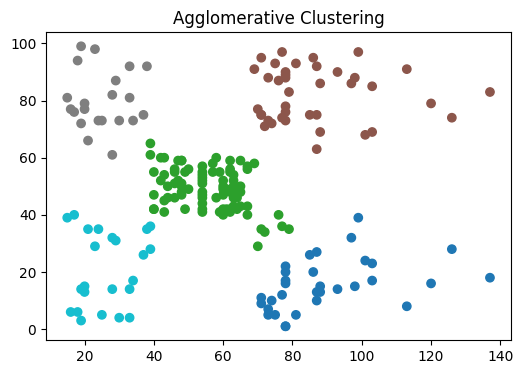

In [19]:
agg=AgglomerativeClustering(n_clusters=5) # we find the optimal clusters above
agg_labels=agg.fit_predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],c=agg_labels, cmap='tab10')
plt.title("Agglomerative Clustering")
plt.show()

## DBSCAN Clustering

 Density-based clustering algorithms group data points into clusters based on regions of high density separated by low-density areas.

 Unlike centroid-based methods like K-Means, these algorithms can detect arbitrary-shaped clusters and handle noise/outliers effectively.

### Core concepts include:

- Core points: Have at least MinPts neighbors within radius eps(epsilion -> radius ).

- Border points: Near a core point but with fewer than MinPts neighbors.

- Noise points: Neither core nor border points.

### Popular algorithms:

- DBSCAN: Expands clusters from core points using density reachability.

- HDBSCAN: Hierarchical extension of DBSCAN, better for varying densities.


useful when the cluster is unknown

- based on two metrics it can decide how many clusters needed

1. eps(episilion)
2. min_samples

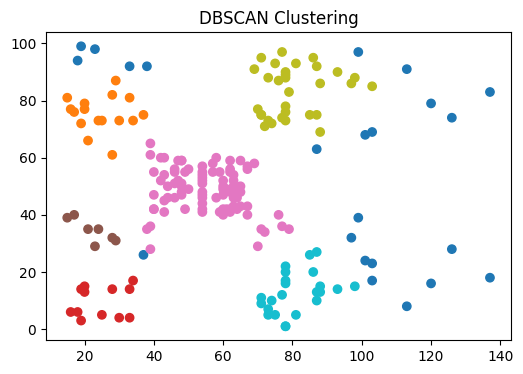

In [20]:
dbscan=DBSCAN(eps=9, min_samples=5) # eps -epsilion(radius)
db_labels=dbscan.fit_predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],c=db_labels, cmap='tab10')
plt.title("DBSCAN Clustering")
plt.show()

# HDBSCAN Clustering


- Improved version of dbscan
- handles clusters of varing density and creates a hierarchy of clusters then selects the best based on the stability
- no need to set epsilion value
- good for real world data

pip install hdbscan


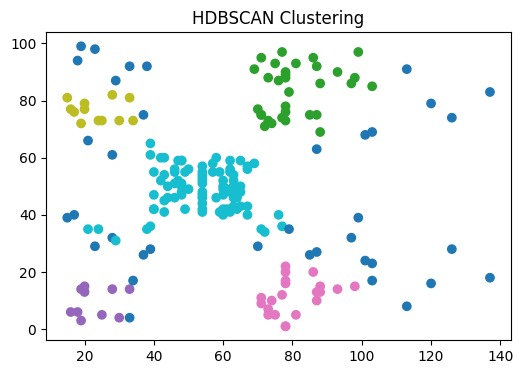

In [21]:
hdb= hdbscan.HDBSCAN(min_cluster_size=5)
hdb_labels=hdb.fit_predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],c=hdb_labels, cmap='tab10')
plt.title("HDBSCAN Clustering")
plt.show()

In [22]:
from sklearn.metrics import silhouette_score

print("K-Means Silhouette Score:", round(silhouette_score(X, kmeans_labels),3))
print("Agglomerative Clustering Silhouette Score:", round(silhouette_score(X, agg_labels),3))
print("DBSCAN Silhouette Score:", round(silhouette_score(X, db_labels),3))
print("HDBSCAN Silhouette Score:", round(silhouette_score(X, hdb_labels),3))


K-Means Silhouette Score: 0.468
Agglomerative Clustering Silhouette Score: 0.553
DBSCAN Silhouette Score: 0.436
HDBSCAN Silhouette Score: 0.381


### PCA
Principal Component Analysis (PCA) is a widely used dimensionality reduction technique in machine learning and statistics. It transforms a large set of correlated variables into a smaller set of uncorrelated variables called principal components.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [24]:
# Feature selection
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
# PCA to reduce to components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [26]:
# optional : check explained variance
print("Explained variance by PCA",pca.explained_variance_ratio_)

Explained variance by PCA [0.50495142 0.49504858]


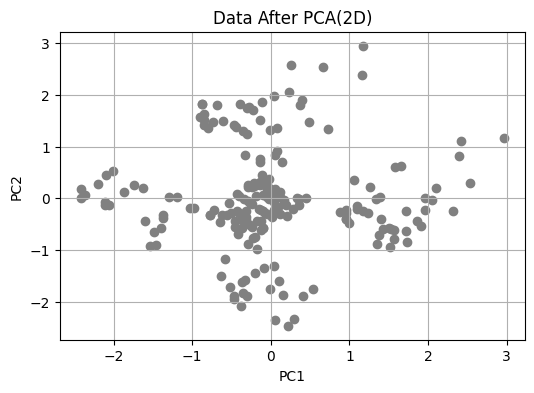

In [27]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1],c='gray')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data After PCA(2D)")
plt.grid(True)
plt.show()

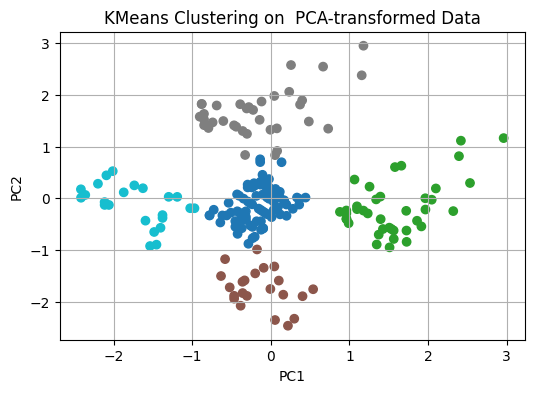

In [28]:
# Kmeans on PCA data

kmeans_pca=KMeans(n_clusters=5, random_state=42)
kmeans_pca_labels=kmeans_pca.fit_predict(X_pca)

# plot clusters
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1],c=kmeans_pca_labels, cmap='tab10')
plt.title("KMeans Clustering on PCA-transformed Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()